# Ecommerce Sales Analysis

## Questions
1. Which products and countries drive revenue? Is revenue concentrated in a small share of products?
2. How does monthly revenue trend, and is the Q4 spike seasonality or growth?
3. What share of revenue comes from repeat vs one-time customers?

## Assumptions
- Revenue = Quantity x UnitPrice
- Cancelled orders (InvoiceNo starting with "C") are excluded from sales
- Rows with no CustomerID are kept for Questions 1-2 but excluded from Question 3

In [20]:
import pandas as pd 
df = pd.read_excel("../data/raw/online retail.xlsx")
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [21]:
import os
p = "../data/raw/online retail.xlsx"
print(os.path.exists(p), os.path.getsize(p))
print(open(p, "rb").read(200))

True 23715344
b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00b\xee\x9dh^\x01\x00\x00\x90\x04\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'


In [22]:
import zipfile
with zipfile.ZipFile("../data/raw/online+retail.zip") as z:
    print(z.namelist())
    z.extractall("../data/raw")

['Online Retail.xlsx']


In [23]:
import pandas as pd
df = pd.read_excel("../data/raw/Online Retail.xlsx")
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [24]:
df.info()
print(df.isna().sum())
print("duplicates:", df.duplicated().sum())
print("cancellations:", df["InvoiceNo"].astype(str).str.startswith("C").sum())
print("quantity <= 0:", (df["Quantity"] <= 0).sum())
print("price <= 0:", (df["UnitPrice"] <= 0).sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
duplicates: 5268
cancellations: 9288
quantity <= 0: 10624
price <= 0: 2517


In [25]:
clean = df.copy()
clean["InvoiceNo"] = clean["InvoiceNo"].astype(str)
clean["StockCode"] = clean["StockCode"].astype(str)
log = []

def drop(name, reason, keep_mask):
    global clean
    before = len(clean)
    clean = clean[keep_mask(clean)]
    log.append({"step": name, "rows_removed": before - len(clean), "reason": reason})

drop("duplicates", "exact duplicate rows", lambda d: ~d.duplicated())
drop("cancellations", "InvoiceNo starts with C (returns, not sales)",
     lambda d: ~d["InvoiceNo"].str.startswith("C"))
drop("bad qty/price", "Quantity or UnitPrice <= 0 (adjustments, write-offs)",
     lambda d: (d["Quantity"] > 0) & (d["UnitPrice"] > 0))
drop("non-product codes", "StockCode not a product (POST, BANK CHARGES, M, etc.)",
     lambda d: d["StockCode"].str.match(r"^\d{5}"))

clean["Revenue"] = clean["Quantity"] * clean["UnitPrice"]
clean["Month"] = clean["InvoiceDate"].dt.to_period("M").astype(str)
clean["HasCustomer"] = clean["CustomerID"].notna()

log.append({"step": "kept NaN CustomerID", "rows_removed": 0,
            "reason": "kept for Q1-Q2; flagged and excluded from Q3 only"})

print(pd.DataFrame(log))
print("raw:", len(df), "-> clean:", len(clean))
print("missing CustomerID share:", round((~clean["HasCustomer"]).mean() * 100, 1), "%")

                  step  rows_removed  \
0           duplicates          5268   
1        cancellations          9251   
2        bad qty/price          2512   
3    non-product codes          2374   
4  kept NaN CustomerID             0   

                                              reason  
0                               exact duplicate rows  
1       InvoiceNo starts with C (returns, not sales)  
2  Quantity or UnitPrice <= 0 (adjustments, write...  
3  StockCode not a product (POST, BANK CHARGES, M...  
4  kept for Q1-Q2; flagged and excluded from Q3 only  
raw: 541909 -> clean: 522504
missing CustomerID share: 25.1 %


                                  Description    Revenue
StockCode                                               
22423                REGENCY CAKESTAND 3 TIER  174156.54
23843             PAPER CRAFT , LITTLE BIRDIE  168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER  104462.75
47566                           PARTY BUNTING   99445.23
85099B                JUMBO BAG RED RETROSPOT   94159.81
23166          MEDIUM CERAMIC TOP STORAGE JAR   81700.92
23084                      RABBIT NIGHT LIGHT   66870.03
22086         PAPER CHAIN KIT 50'S CHRISTMAS    64875.59
84879           ASSORTED COLOUR BIRD ORNAMENT   58927.62
79321                           CHILLI LIGHTS   54096.36
Country
United Kingdom    85.1
Netherlands        2.8
EIRE               2.6
Germany            2.0
France             1.8
Australia          1.3
Spain              0.5
Switzerland        0.5
Japan              0.4
Belgium            0.4
Name: Revenue, dtype: float64


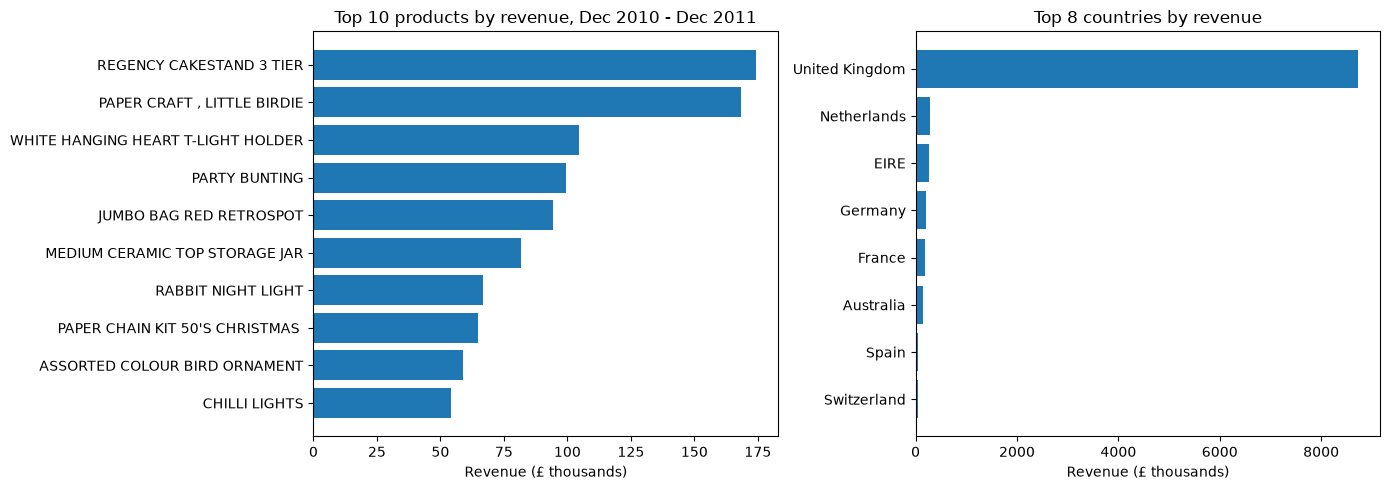

In [26]:
import numpy as np
import matplotlib.pyplot as plt

prod = (clean.groupby("StockCode")
        .agg(Description=("Description", "first"), Revenue=("Revenue", "sum"))
        .sort_values("Revenue", ascending=False))
country = clean.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

print(prod.head(10))
print((country.head(10) / country.sum() * 100).round(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
top = prod.head(10)[::-1]
ax[0].barh(top["Description"], top["Revenue"] / 1000)
ax[0].set_title("Top 10 products by revenue, Dec 2010 - Dec 2011")
ax[0].set_xlabel("Revenue (£ thousands)")
c = country.head(8)[::-1]
ax[1].barh(c.index, c.values / 1000)
ax[1].set_title("Top 8 countries by revenue")
ax[1].set_xlabel("Revenue (£ thousands)")
plt.tight_layout()
plt.show()

In [27]:
big = clean[clean["Quantity"] >= 50000]
print(big[["InvoiceNo", "Description", "Quantity", "Revenue", "InvoiceDate"]])

# find matching cancellations in the raw data
raw_c = df[df["InvoiceNo"].astype(str).str.startswith("C") & (df["Quantity"] <= -50000)]
print(raw_c[["InvoiceNo", "Description", "Quantity", "InvoiceDate"]])

       InvoiceNo                     Description  Quantity   Revenue  \
61619     541431  MEDIUM CERAMIC TOP STORAGE JAR     74215   77183.6   
540421    581483     PAPER CRAFT , LITTLE BIRDIE     80995  168469.6   

               InvoiceDate  
61619  2011-01-18 10:01:00  
540421 2011-12-09 09:15:00  
       InvoiceNo                     Description  Quantity         InvoiceDate
61624    C541433  MEDIUM CERAMIC TOP STORAGE JAR    -74215 2011-01-18 10:17:00
540422   C581484     PAPER CRAFT , LITTLE BIRDIE    -80995 2011-12-09 09:27:00


In [28]:
clean = clean[clean["Quantity"] < 50000].copy()
log.append({"step": "cancelled bulk orders",
            "rows_removed": len(big),
            "reason": "orders of 50k+ units, cancelled same day; originals remained after cancellations were dropped"})
print(len(clean))

522502


## Data issue found: cancelled bulk orders
Two orders of 74,215 and 80,995 units (Medium Ceramic Top Storage Jar, Paper Craft Little Birdie) were cancelled within minutes. Dropping the cancellation rows left the originals behind, which inflated revenue by roughly £230k. I removed both orders from the analysis.

In [29]:
clean.to_csv("../data/processed/clean_retail.csv", index=False)
print("saved", len(clean))

saved 522502


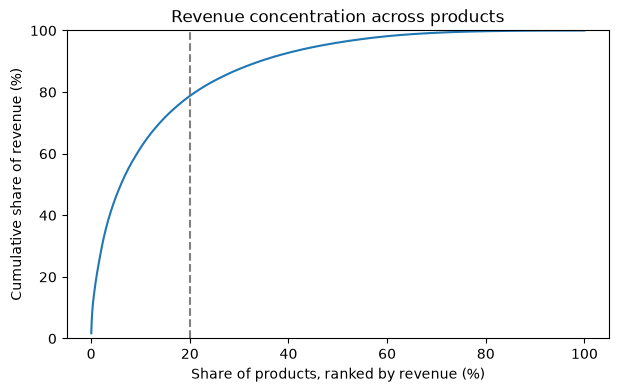

In [30]:
cum = prod["Revenue"].cumsum() / prod["Revenue"].sum() * 100
x = np.arange(1, len(cum) + 1) / len(cum) * 100

plt.figure(figsize=(7, 4))
plt.plot(x, cum.values)
plt.axvline(20, ls="--", color="grey")
plt.xlabel("Share of products, ranked by revenue (%)")
plt.ylabel("Cumulative share of revenue (%)")
plt.title("Revenue concentration across products")
plt.ylim(0, 100)
plt.show()

In [31]:
inv_idx, inv_codes = pd.factorize(clean["InvoiceNo"])
sc_idx, sc_codes = pd.factorize(clean["StockCode"])
rev = clean["Revenue"].to_numpy()
rng = np.random.default_rng(42)

def top20_share(w):
    r = np.bincount(sc_idx, weights=rev * w, minlength=len(sc_codes))
    r = np.sort(r[r > 0])[::-1]
    k = int(np.ceil(0.2 * len(r)))
    return r[:k].sum() / r.sum() * 100

point = top20_share(np.ones(len(rev)))
boot = []
for _ in range(200):
    counts = np.bincount(rng.integers(0, len(inv_codes), len(inv_codes)),
                         minlength=len(inv_codes))
    boot.append(top20_share(counts[inv_idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Top 20% of products = {point:.1f}% of revenue (95% CI {lo:.1f}-{hi:.1f}%)")
print(f"UK share of revenue: {country['United Kingdom'] / country.sum() * 100:.1f}%")

Top 20% of products = 78.3% of revenue (95% CI 77.6-78.7%)
UK share of revenue: 85.1%


## Question 1: Which products and countries drive revenue?
**Answer:** The top products are Regency Cakestand 3 Tier, White Hanging Heart T-Light Holder and Party Bunting. The UK accounts for 84.8% of revenue. The top 20% of products generate 78.3% of revenue (95% CI 77.6-78.7%), so revenue is highly concentrated.

**Confounders and biases:**
- Many customers are wholesalers, so a few bulk orders can make a product look like a top seller.
- Two cancelled bulk orders (74k and 81k units) were removed because they inflated product revenue.
- 25% of rows have no CustomerID.
- One year of data from one UK retailer, so it may not generalize.

           Revenue
Month             
2010-12   775572.0
2011-01   593178.0
2011-02   507783.0
2011-03   689708.0
2011-04   515355.0
2011-05   739914.0
2011-06   737559.0
2011-07   688145.0
2011-08   724197.0
2011-09  1028314.0
2011-10  1103311.0
2011-11  1452113.0
2011-12   446018.0


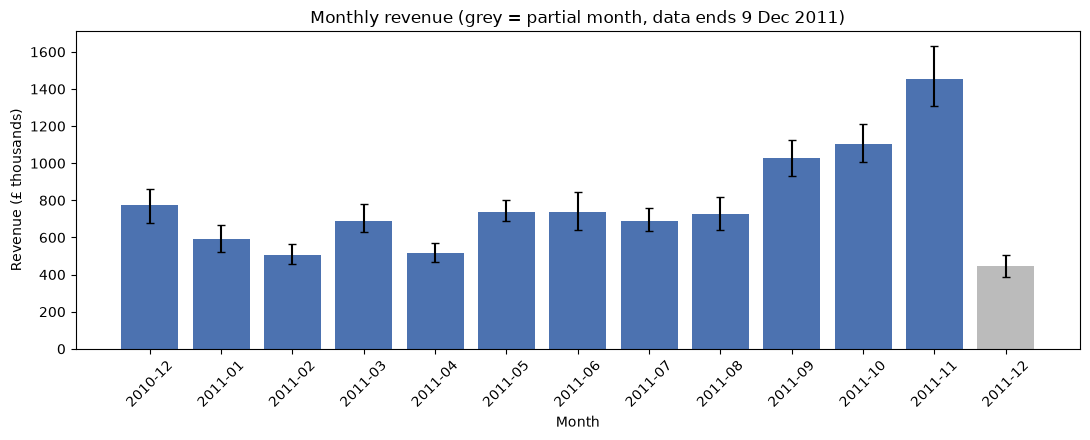

In [32]:
monthly = clean.groupby("Month")["Revenue"].sum().to_frame()
print(monthly.round(0))

# 95% CI by resampling invoices within each month
inv = clean.groupby(["Month", "InvoiceNo"])["Revenue"].sum().reset_index()
rng = np.random.default_rng(42)
lo, hi = [], []
for m in monthly.index:
    v = inv.loc[inv["Month"] == m, "Revenue"].to_numpy()
    b = [rng.choice(v, len(v)).sum() for _ in range(300)]
    lo.append(np.percentile(b, 2.5))
    hi.append(np.percentile(b, 97.5))
monthly["lo"], monthly["hi"] = lo, hi

colors = ["#4C72B0"] * (len(monthly) - 1) + ["#BBBBBB"]  # last month is partial
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(monthly.index, monthly["Revenue"] / 1000, color=colors,
       yerr=[(monthly["Revenue"] - monthly["lo"]) / 1000,
             (monthly["hi"] - monthly["Revenue"]) / 1000], capsize=3)
ax.set_title("Monthly revenue (grey = partial month, data ends 9 Dec 2011)")
ax.set_ylabel("Revenue (£ thousands)")
ax.set_xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
d = clean[(clean["InvoiceDate"].dt.day <= 9) &
          (clean["Month"].isin(["2010-12", "2011-12"]))]
dec = d.groupby("Month")["Revenue"].sum()
print(dec.round(0))
print("Change 1-9 Dec 2011 vs 2010:", round((dec["2011-12"] / dec["2010-12"] - 1) * 100, 1), "%")

Month
2010-12    407989.0
2011-12    446018.0
Name: Revenue, dtype: float64
Change 1-9 Dec 2011 vs 2010: 9.3 %


## Question 2: Is the Q4 spike growth or seasonality?
**Answer:** Revenue is fairly flat at about £500-780k per month from January to August, then rises to £1.03M in September, £1.10M in October and £1.45M in November. September to November accounts for 37.5% of the 12-month total (December 2010 to November 2011), against 25% if revenue were spread evenly. November is about 2.2 times the January-August monthly average.

**Why this can't be fully explained:** the data covers only one year, so a seasonal holiday peak and real business growth look identical. The only like-for-like check is 1-9 December 2011 vs 1-9 December 2010: £446k vs £408k, a 9.3% increase. That is a rough signal from one 9-day window, so it suggests modest growth but can't separate it from seasonality.
**Caveats:**
- December 2011 is a partial month (data ends 9 December), so it is shown in grey and excluded from totals.
- Error bars are 95% intervals from resampling invoices; wide bars reflect a few large wholesale orders.
- Many customers are wholesalers, who may stock up ahead of Christmas, which exaggerates the seasonal peak.

In [34]:
cust = clean[clean["HasCustomer"]].copy()
orders = cust.groupby("CustomerID")["InvoiceNo"].nunique()
cust["Type"] = np.where(cust["CustomerID"].map(orders) >= 2, "Repeat", "One-time")

by_cust = cust.groupby(["CustomerID", "Type"])["Revenue"].sum().reset_index()
summary = by_cust.groupby("Type").agg(Customers=("CustomerID", "count"),
                                      Revenue=("Revenue", "sum"))
summary["Customer share %"] = (summary["Customers"] / summary["Customers"].sum() * 100).round(1)
summary["Revenue share %"] = (summary["Revenue"] / summary["Revenue"].sum() * 100).round(1)
print(summary)

          Customers     Revenue  Customer share %  Revenue share %
Type                                                              
One-time       1505   549425.20              34.7              6.5
Repeat         2828  7942149.24              65.3             93.5


Repeat customers' revenue share: 93.5% (95% CI 92.5-94.5%)


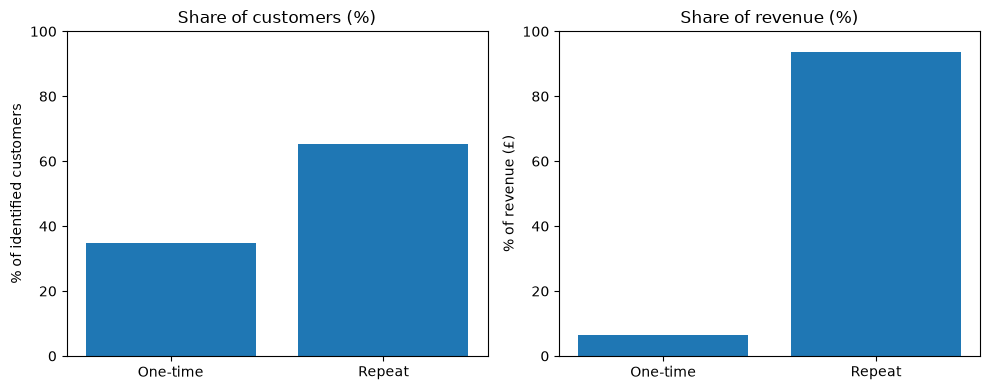

In [35]:
rng = np.random.default_rng(42)
is_rep = (by_cust["Type"] == "Repeat").to_numpy()
rv = by_cust["Revenue"].to_numpy()
boot = []
for _ in range(1000):
    i = rng.integers(0, len(rv), len(rv))
    boot.append(rv[i][is_rep[i]].sum() / rv[i].sum() * 100)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Repeat customers' revenue share: {summary.loc['Repeat', 'Revenue share %']}% (95% CI {lo:.1f}-{hi:.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(summary.index, summary["Customer share %"])
ax[0].set_title("Share of customers (%)")
ax[1].bar(summary.index, summary["Revenue share %"])
ax[1].set_title("Share of revenue (%)")
for a in ax:
    a.set_ylim(0, 100)
ax[0].set_ylabel("% of identified customers")
ax[1].set_ylabel("% of revenue (£)")
plt.tight_layout()
plt.show()

## Question 3: How much revenue comes from repeat vs one-time customers?
**Answer:** Of the 4,333 customers with a known ID, 65.3% placed two or more orders. They generate 93.5% of revenue (95% CI X-X%). The 34.7% who ordered only once generate just 6.5%. Repeat customers are by far the most valuable group.

**Confounders and biases:**
- 25% of rows have no CustomerID and are excluded here, so this covers only identified customers.
- The data covers one year, so someone who first bought in late 2011 has had little time to become a repeat customer. This understates repeat behavior among newer customers.
- Repeat customers also have more orders, so part of their revenue share is simply because they bought more times, not because each order is worth more.
- Many customers are wholesalers, whose large orders can dominate revenue.